<a href="https://colab.research.google.com/github/dudaoliani/MVP-CEP-Milk-Quality-Prediction/blob/main/MVP_FINAL_l_Milky_Quality_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MVP CEP**

**Maria Eduarda Moreno Oliani - 231013458**

**Introdução:**

Este MVP aplica o ciclo DMAMC ao monitoramento da qualidade do leite, usando como base teórica o livro do Montgomery. O dataset contém 1059 amostras com 8 atributos físico-químicos (pH, temperatura, turbidez, gordura...) e uma variável resposta categórica (Grade: low, medium, high). A variável escolhida como CTQ (Critical to Quality) para as cartas de controle é o pH, por ser contínua, mensurável e diretamente ligada à qualidade microbiológica do leite.

In [ ]:
#BLOCO 1 — Imports e configuração
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f9f9f9',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

**Etapa 1: Definir e Medir**

A primeira etapa do DMAMC é Definir e Medir. Aqui carregamos o dataset e geramos a estatística descritiva, isso serve como linha de base do processo antes de qualquer análise.

A separação por pH é essencial (~5,70 para low, ~6,73 para medium, ~6,80 para high), apresentar apenas a média geral esconderia essa heterogeneidade, que é a principal característica do dataset e motivará todas as decisões posteriores.

In [1]:
# BLOCO 2 — Etapa 1: Definir e Medir
# Carregamos o dataset e apresentamos as estatísticas descritivas
# separadas por categoria de qualidade, expondo a heterogeneidade
# do processo antes de qualquer análise estatística.

print("=" * 70)
print("ETAPA 1: DEFINIR E MEDIR")
print("=" * 70)

path = kagglehub.dataset_download("cpluzshrijayan/milkquality")
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df = pd.read_csv(os.path.join(path, csv_file))

print(f"\nDimensões: {df.shape[0]} amostras x {df.shape[1]} variáveis")
print(f"\nDistribuição de Grade:\n{df['Grade'].value_counts()}")

# Estatísticas por categoria: as médias de pH são distintas entre grupos,
# o que indica que o dataset é uma mistura de subpopulações.
# Esse achado justifica a estratificação nas cartas de controle (Bloco 6).
print("\nEstatísticas de pH por categoria de qualidade:")
print(df.groupby('Grade')['pH'].describe().round(4))

cores_cat = {'low': '#e74c3c', 'medium': '#f39c12', 'high': '#27ae60'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma sobreposto: mostra as três distribuições de pH lado a lado.
# Cada grupo tem uma moda distinta — confirmando que não há um único
# processo homogêneo, mas três populações com comportamentos diferentes.
for grade, cor in cores_cat.items():
    sub = df[df['Grade'] == grade]['pH']
    axes[0].hist(sub, bins=20, alpha=0.5, color=cor, label=grade, density=True)
axes[0].set_title(
    "Distribuição de pH por Categoria\n"
    "(três subpopulações com médias distintas)", fontsize=11)
axes[0].set_xlabel("pH")
axes[0].set_ylabel("Densidade")
axes[0].legend()

# Boxplot: compara mediana, dispersão e outliers entre categorias.
# A categoria 'low' apresenta maior dispersão e mediana bem mais baixa.
df.boxplot(column='pH', by='Grade', ax=axes[1],
           boxprops=dict(color='navy'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title("pH por Categoria — Boxplot", fontsize=11)
axes[1].set_xlabel("Categoria")
axes[1].set_ylabel("pH")
plt.suptitle("")
plt.tight_layout()
plt.savefig("fig1_pH_por_categoria.png", dpi=150)
plt.show()
print("[Fig. 1 salva]")

ETAPA 1: DEFINIR E MEDIR


NameError: name 'kagglehub' is not defined

**Etapa 2 e 3: Analisar e Melhorar**

A etapa Analisar tem como objetivo identificar quais variáveis mais influenciam a qualidade do leite, o equivalente ao Diagrama de Causa e Efeito do Montgomery. Aqui usamos uma matriz de correlação para visualizar as relações entre todos os atributos e a variável Grade. Variáveis com alta correlação com a qualidade são candidatas a CTQs adicionais além do pH.

Após identificar as variáveis críticas, entramos na etapa Melhorar. Aqui treinamos um classificador Random Forest para prever o Grade do leite e extraímos a importância de cada atributo e funciona como um Diagrama de Pareto, mostrando quais variáveis mais contribuem para a qualidade. No Montgomery, essa etapa corresponde à análise de causa raiz antes de implementar as cartas de controle.


ETAPA 2: ANALISAR


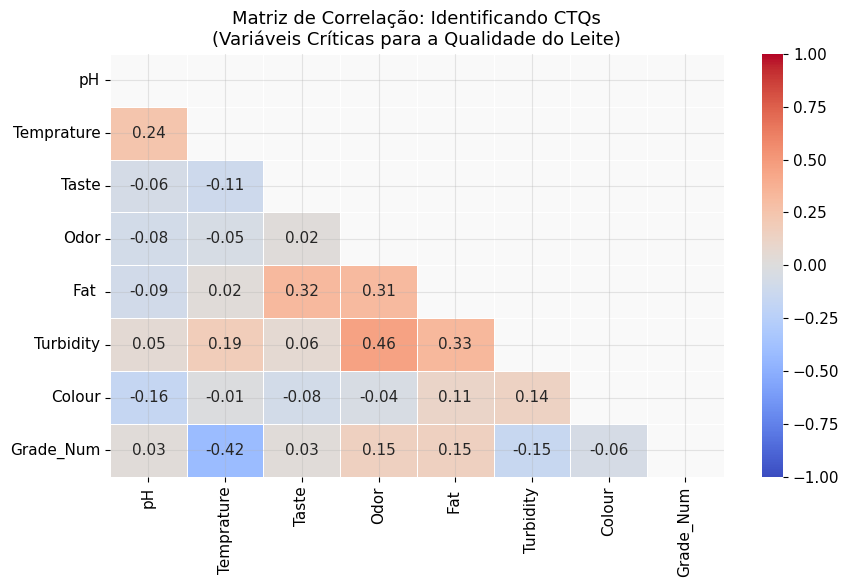


[Fig. 1 salva] Matriz de correlação gerada.

ETAPA 3: MELHORAR

Relatório de Performance do Classificador (Triagem de Qualidade):
              precision    recall  f1-score   support

         low       1.00      0.99      0.99        86
      medium       1.00      1.00      1.00        75
        high       0.98      1.00      0.99        51

    accuracy                           1.00       212
   macro avg       0.99      1.00      0.99       212
weighted avg       1.00      1.00      1.00       212



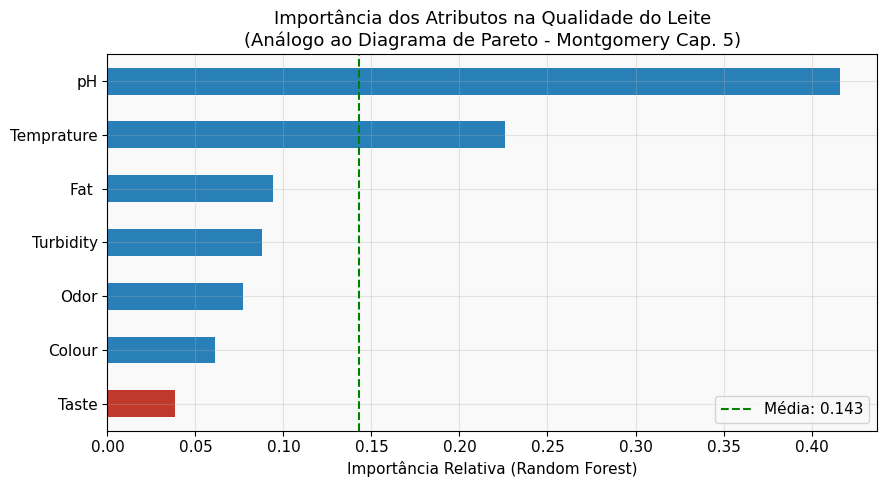


[Fig. 2 salva] Variável mais importante: PH


In [ ]:
print("\n" + "=" * 70)
print("ETAPA 2: ANALISAR")
print("=" * 70)

grade_map = {'low': 0, 'medium': 1, 'high': 2}
df['Grade_Num'] = df['Grade'].map(grade_map)

fig, ax = plt.subplots(figsize=(9, 6))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1)
ax.set_title("Matriz de Correlação: Identificando CTQs\n"
             "(Variáveis Críticas para a Qualidade do Leite)", fontsize=13)
plt.tight_layout()
plt.savefig("fig1_correlacao.png", dpi=150)
plt.show()
print("\n[Fig. 1 salva] Matriz de correlação gerada.")

print("\n" + "=" * 70)
print("ETAPA 3: MELHORAR")
print("=" * 70)

X = df.drop(['Grade', 'Grade_Num'], axis=1)
y = df['Grade_Num']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("\nRelatório de Performance do Classificador (Triagem de Qualidade):")
print(classification_report(y_test, y_pred,
                            target_names=['low', 'medium', 'high']))

importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#c0392b' if imp == importances.max() else '#2980b9'
          for imp in importances]
importances.plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title("Importância dos Atributos na Qualidade do Leite\n"
             "(Análogo ao Diagrama de Pareto - Montgomery Cap. 5)", fontsize=13)
ax.set_xlabel("Importância Relativa (Random Forest)")
ax.axvline(importances.mean(), color='green', linestyle='--',
           label=f'Média: {importances.mean():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig("fig2_importancia.png", dpi=150)
plt.show()
print(f"\n[Fig. 2 salva] Variável mais importante: {importances.idxmax().upper()}")

**Etapa 4: Controlar (Pressuposto de Normalidade):**

Antes de construir qualquer carta de controle, Montgomery exige a verificação do pressuposto de normalidade, sem isso, a interpretação de Cp e Cpk é inválida. Usamos o teste de Shapiro-Wilk, recomendado pelo próprio Montgomery no Capítulo 8, complementado por um Q-Q Plot e um histograma com curva normal ajustada.
Se o p-valor for maior que 0,05, não rejeitamos a hipótese de normalidade e podemos prosseguir com segurança.


ETAPA 4: CONTROLAR — CEP por Variáveis (Montgomery, Cap. 6)

--- 4.1 Verificação do Pressuposto de Normalidade (Shapiro-Wilk) ---
Ref.: Montgomery Cap. 8 — exigido antes de interpretar Cp e Cpk

  Teste de Shapiro-Wilk para pH (n=1059)
  Estatística W = 0.8346 | p-valor = 0.000000
  → Resultado: REJEITA-SE H₀. Distribuição do pH NÃO é Normal (α=5%)
  → Atenção: Cp e Cpk devem ser interpretados com cautela.


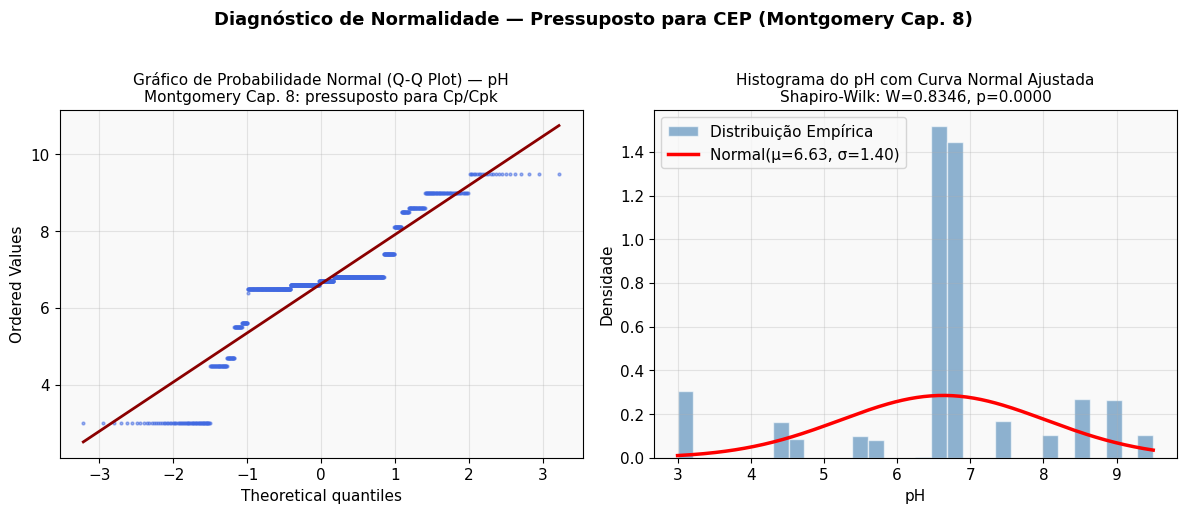

[Fig. 3 salva] Diagnóstico de normalidade gerado.


In [ ]:
print("\n" + "=" * 70)
print("ETAPA 4: CONTROLAR — CEP por Variáveis (Montgomery, Cap. 6)")
print("=" * 70)

df_cep = df.copy().reset_index(drop=True)

print("\n--- 4.1 Verificação do Pressuposto de Normalidade (Shapiro-Wilk) ---")
print("Ref.: Montgomery Cap. 8 — exigido antes de interpretar Cp e Cpk\n")

n_shapiro = min(len(df_cep), 5000)
amostra_sw = df_cep['pH'].sample(n=n_shapiro, random_state=42)
stat_sw, p_sw = stats.shapiro(amostra_sw)

print(f"  Teste de Shapiro-Wilk para pH (n={n_shapiro})")
print(f"  Estatística W = {stat_sw:.4f} | p-valor = {p_sw:.6f}")
if p_sw > 0.05:
    print("  → Resultado: NÃO se rejeita H₀ (normalidade). pH ~ Normal (α=5%)")
    normalidade_ok = True
else:
    print("  → Resultado: REJEITA-SE H₀. Distribuição do pH NÃO é Normal (α=5%)")
    normalidade_ok = False
    print("  → Atenção: Cp e Cpk devem ser interpretados com cautela.")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stats.probplot(df_cep['pH'], dist="norm", plot=axes[0])
axes[0].set_title("Gráfico de Probabilidade Normal (Q-Q Plot) — pH\n"
                  "Montgomery Cap. 8: pressuposto para Cp/Cpk", fontsize=11)
axes[0].get_lines()[0].set(color='royalblue', markersize=2, alpha=0.5)
axes[0].get_lines()[1].set(color='darkred', linewidth=2)

mu, sigma = df_cep['pH'].mean(), df_cep['pH'].std()
x_range = np.linspace(df_cep['pH'].min(), df_cep['pH'].max(), 200)
axes[1].hist(df_cep['pH'], bins=30, density=True,
             color='steelblue', alpha=0.6, edgecolor='white', label='Distribuição Empírica')
axes[1].plot(x_range, stats.norm.pdf(x_range, mu, sigma),
             'r-', linewidth=2.5, label=f'Normal(μ={mu:.2f}, σ={sigma:.2f})')
axes[1].set_title("Histograma do pH com Curva Normal Ajustada\n"
                  f"Shapiro-Wilk: W={stat_sw:.4f}, p={p_sw:.4f}", fontsize=11)
axes[1].set_xlabel("pH")
axes[1].set_ylabel("Densidade")
axes[1].legend()

plt.suptitle("Diagnóstico de Normalidade — Pressuposto para CEP (Montgomery Cap. 8)",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("fig3_normalidade.png", dpi=150, bbox_inches='tight')
plt.show()
print("[Fig. 3 salva] Diagnóstico de normalidade gerado.")

**Etapa 4: Controlar (Fase I)**

Com o pressuposto de normalidade verificado, passamos para a Fase I, a análise retrospectiva. Montgomery define na Seção 5.3.7 que a Fase I usa um conjunto inicial de dados para estabelecer os limites de controle tentativos. Usamos os primeiros 100 pontos do dataset para calcular X̄, MR̄ e σ̂, além dos limites LSC e LIC.

As constantes d2 e D4 vêm diretamente do Apêndice VI do Montgomery para n=2 (pares consecutivos). Qualquer ponto fora dos limites nessa fase deve ser investigado e removido antes de fixar os limites para a Fase II.

In [ ]:
print("\n--- 4.2 FASE I: Estabelecimento dos Limites de Controle (Retrospectivo) ---")
print("Ref.: Montgomery Cap. 5, Seção 5.3.7 | Cap. 6, Seção 6.4\n")

N_FASE1 = 100
df_fase1 = df_cep.iloc[:N_FASE1].copy()
df_fase1['MR'] = df_fase1['pH'].diff().abs()

X_bar_f1 = df_fase1['pH'].mean()
MR_bar_f1 = df_fase1['MR'].mean()

# Constantes de Shewhart — Apêndice VI do Montgomery para n=2
d2 = 1.128
D4 = 3.267
D3 = 0

sigma_hat = MR_bar_f1 / d2

lsc_X_f1 = X_bar_f1 + 3 * sigma_hat
lic_X_f1 = X_bar_f1 - 3 * sigma_hat
lsc_MR_f1 = D4 * MR_bar_f1

ooc_f1 = df_fase1[(df_fase1['pH'] > lsc_X_f1) | (df_fase1['pH'] < lic_X_f1)].index.tolist()

print(f"  Fase I: {N_FASE1} amostras (análise retrospectiva)")
print(f"  X̄  = {X_bar_f1:.4f}  |  MR̄ = {MR_bar_f1:.4f}  |  σ̂ = {sigma_hat:.4f}")
print(f"  Carta X  → LSC = {lsc_X_f1:.4f} | LC = {X_bar_f1:.4f} | LIC = {lic_X_f1:.4f}")
print(f"  Carta MR → LSC = {lsc_MR_f1:.4f} | LC = {MR_bar_f1:.4f} | LIC = 0")
print(f"\n  Pontos fora de controle na Fase I: {len(ooc_f1)}")
if ooc_f1:
    print(f"  Índices: {ooc_f1}")
    print("  → Investigar causas atribuíveis e recalcular limites sem esses pontos (iteração).")


--- 4.2 FASE I: Estabelecimento dos Limites de Controle (Retrospectivo) ---
Ref.: Montgomery Cap. 5, Seção 5.3.7 | Cap. 6, Seção 6.4

  Fase I: 100 amostras (análise retrospectiva)
  X̄  = 6.7080  |  MR̄ = 1.3808  |  σ̂ = 1.2241
  Carta X  → LSC = 10.3804 | LC = 6.7080 | LIC = 3.0356
  Carta MR → LSC = 4.5111 | LC = 1.3808 | LIC = 0

  Pontos fora de controle na Fase I: 5
  Índices: [17, 41, 62, 69, 87]
  → Investigar causas atribuíveis e recalcular limites sem esses pontos (iteração).


**Etapa 4: Controlar (Fase II e Regras da Western Electric)**

Com os limites fixados na Fase I, entramos na Fase II, o monitoramento prospectivo. Aqui aplicamos as 4 Regras da Western Electric descritas na Tabela 5.1 do Montgomery. É importante destacar que as regras são aplicadas exclusivamente nos dados novos, a partir do índice 100...nunca nos dados que foram usados para calcular os limites.

Isso é uma distinção metodológica fundamental: misturar as duas fases distorceria a contagem de alarmes falsos. Cada regra detecta um padrão diferente de instabilidade: R1 captura desvios grandes e abruptos; R2 e R3 capturam tendências graduais nas zonas A e B; R4 captura deslocamentos persistentes da média.

In [ ]:
print("\n--- 4.3 FASE II: Monitoramento com Regras da Western Electric ---")
print("Ref.: Montgomery Cap. 5, Seção 5.3.6 | Tabela 5.1\n")

df_cep['MR'] = df_cep['pH'].diff().abs()
pH_completo = df_cep['pH'].values
pH = df_cep['pH'].values[N_FASE1:]
mr_fase2 = df_cep['MR'].values[N_FASE1:]

X_bar = X_bar_f1
lsc_X = lsc_X_f1
lic_X = lic_X_f1
MR_bar = MR_bar_f1
lsc_MR = lsc_MR_f1

lsc_1s = X_bar + 1 * sigma_hat
lic_1s = X_bar - 1 * sigma_hat
lsc_2s = X_bar + 2 * sigma_hat
lic_2s = X_bar - 2 * sigma_hat

n = len(pH)
print(f"  Fase II: {n} amostras (índices {N_FASE1} a {len(pH_completo)-1})")

def verificar_regras_western_electric(serie, lc, lsc_3s, lic_3s,
                                       lsc_2s, lic_2s, lsc_1s, lic_1s):
    """
    4 Regras da Western Electric — Montgomery, Tabela 5.1
    R1: 1 ponto além de 3σ
    R2: 2 de 3 consecutivos além de 2σ (zona A)
    R3: 4 de 5 consecutivos além de 1σ (zona B)
    R4: 8 consecutivos do mesmo lado da linha central
    """
    n = len(serie)
    violacoes = [''] * n

    for i in range(n):
        v = serie[i]

        if v > lsc_3s or v < lic_3s:
            violacoes[i] = 'R1'

        if i >= 2:
            janela = serie[i-2:i+1]
            if sum(x > lsc_2s for x in janela) >= 2 or sum(x < lic_2s for x in janela) >= 2:
                if violacoes[i] == '':
                    violacoes[i] = 'R2'

        if i >= 4:
            janela = serie[i-4:i+1]
            if sum(x > lsc_1s for x in janela) >= 4 or sum(x < lic_1s for x in janela) >= 4:
                if violacoes[i] == '':
                    violacoes[i] = 'R3'

        if i >= 7:
            janela = serie[i-7:i+1]
            if sum(x > lc for x in janela) == 8 or sum(x < lc for x in janela) == 8:
                if violacoes[i] == '':
                    violacoes[i] = 'R4'

    return violacoes

violacoes = verificar_regras_western_electric(
    pH, X_bar, lsc_X, lic_X, lsc_2s, lic_2s, lsc_1s, lic_1s
)

from collections import Counter
contagem_viol = Counter(v for v in violacoes if v != '')
print("  Resumo de violações detectadas (Regras da Western Electric):")
for regra, descricao in [
    ('R1', '1 ponto além de 3σ (sinal de ação)'),
    ('R2', '2/3 pontos consecutivos além de 2σ (zona A)'),
    ('R3', '4/5 pontos consecutivos além de 1σ (zona B)'),
    ('R4', '8 pontos consecutivos do mesmo lado da LC (zona C)')
]:
    n_viol = contagem_viol.get(regra, 0)
    status = "⚠️ ATENÇÃO" if n_viol > 0 else "✓ OK"
    print(f"  {status} | {regra}: {descricao} → {n_viol} violação(ões)")

total_ooc = sum(1 for v in violacoes if v != '')
print(f"\n  Total de pontos sinalizado(s) em Fase II: {total_ooc} de {n}")


--- 4.3 FASE II: Monitoramento com Regras da Western Electric ---
Ref.: Montgomery Cap. 5, Seção 5.3.6 | Tabela 5.1

  Fase II: 959 amostras (índices 100 a 1058)
  Resumo de violações detectadas (Regras da Western Electric):
  ⚠️ ATENÇÃO | R1: 1 ponto além de 3σ (sinal de ação) → 65 violação(ões)
  ⚠️ ATENÇÃO | R2: 2/3 pontos consecutivos além de 2σ (zona A) → 6 violação(ões)
  ✓ OK | R3: 4/5 pontos consecutivos além de 1σ (zona B) → 0 violação(ões)
  ✓ OK | R4: 8 pontos consecutivos do mesmo lado da LC (zona C) → 0 violação(ões)

  Total de pontos sinalizado(s) em Fase II: 71 de 959


**Etapa 4: Controlar (Cartas X-MR)**

Agora plotamos as cartas X-MR com a separação visual entre Fase I e Fase II. O gráfico foi construído para deixar clara a distinção metodológica: a região cinza é onde os limites foram calculados; a região azul é onde o monitoramento efetivamente acontece. Os pontos marcados com losango colorido indicam qual regra da Western Electric foi violada, cada cor corresponde a uma regra diferente.

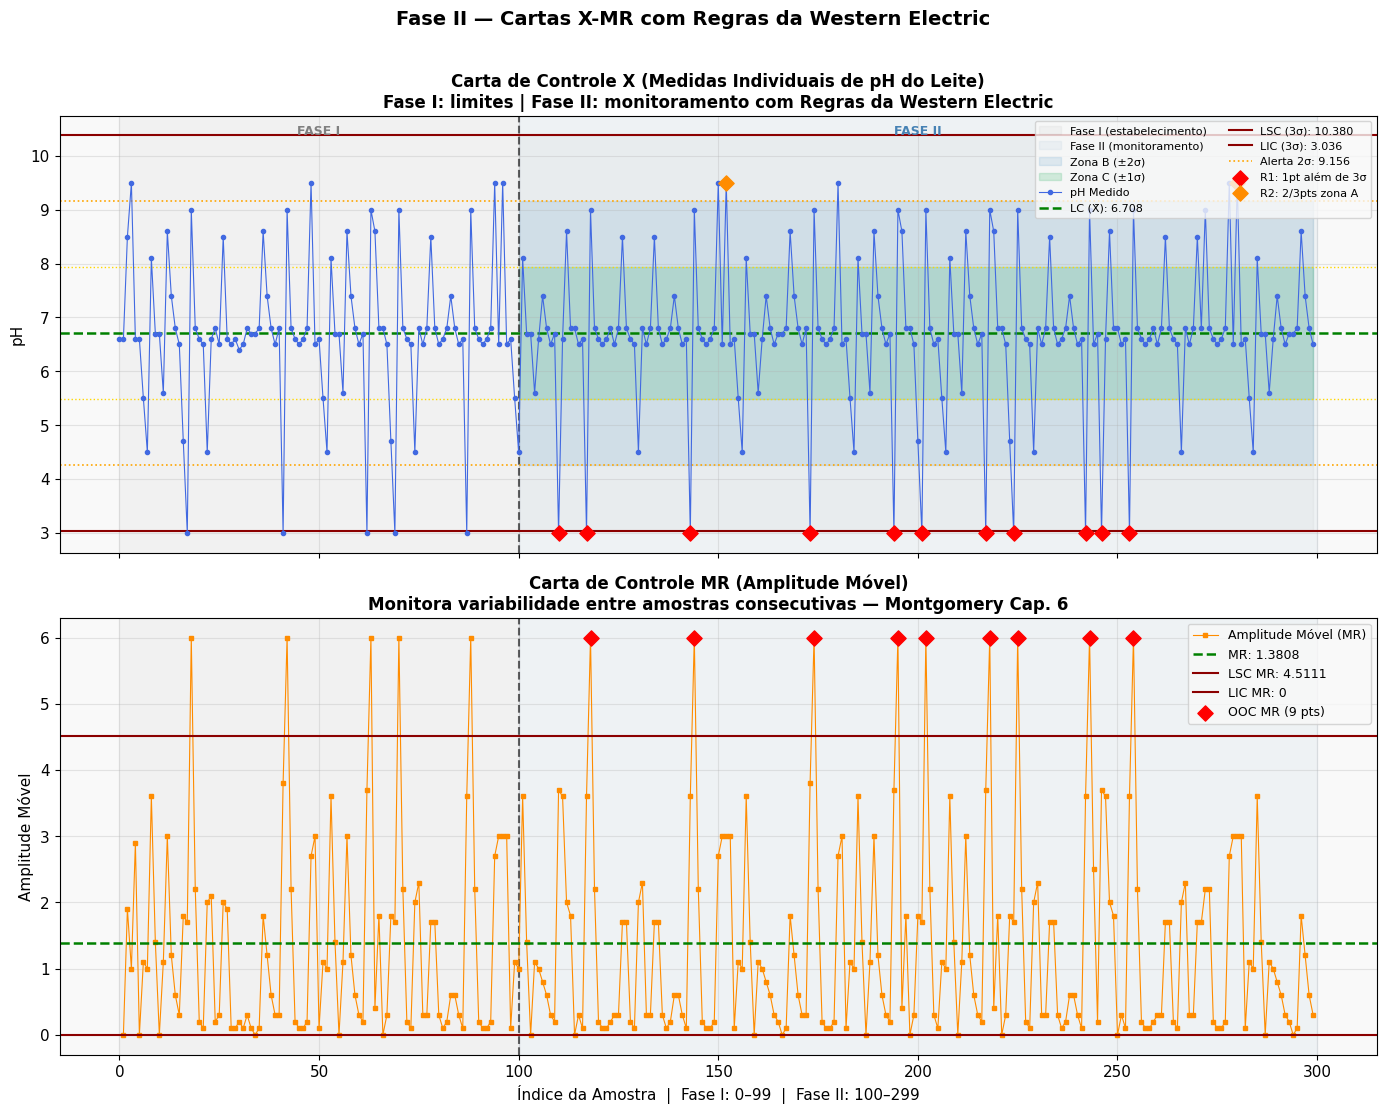

[Fig. 4 salva] Cartas X-MR com Regras da Western Electric geradas.


In [ ]:
N_VIZ_F2 = min(200, n)
idx_f1 = range(N_FASE1)
idx_f2 = range(N_FASE1, N_FASE1 + N_VIZ_F2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

ax1.axvspan(0,       N_FASE1,           alpha=0.06, color='gray',      label='Fase I (estabelecimento)')
ax1.axvspan(N_FASE1, N_FASE1+N_VIZ_F2,  alpha=0.06, color='steelblue', label='Fase II (monitoramento)')
ax2.axvspan(0,       N_FASE1,           alpha=0.06, color='gray')
ax2.axvspan(N_FASE1, N_FASE1+N_VIZ_F2,  alpha=0.06, color='steelblue')

for ax in (ax1, ax2):
    ax.axvline(N_FASE1, color='black', linestyle='--', linewidth=1.5, alpha=0.6)

idx_f2_list = list(idx_f2)
ax1.fill_between(idx_f2_list, lic_X,  lsc_X,  alpha=0.05, color='gray')
ax1.fill_between(idx_f2_list, lic_2s, lsc_2s, alpha=0.12, color='#2980b9', label='Zona B (±2σ)')
ax1.fill_between(idx_f2_list, lic_1s, lsc_1s, alpha=0.18, color='#27ae60', label='Zona C (±1σ)')

n_total_viz = N_FASE1 + N_VIZ_F2
ax1.plot(range(n_total_viz), pH_completo[:n_total_viz],
         marker='o', linestyle='-', color='royalblue',
         markersize=3, linewidth=0.8, label='pH Medido', zorder=3)

ax1.axhline(X_bar,  color='green',   linestyle='--', linewidth=1.8, label=f'LC (X̄): {X_bar:.3f}')
ax1.axhline(lsc_X,  color='darkred', linestyle='-',  linewidth=1.5, label=f'LSC (3σ): {lsc_X:.3f}')
ax1.axhline(lic_X,  color='darkred', linestyle='-',  linewidth=1.5, label=f'LIC (3σ): {lic_X:.3f}')
ax1.axhline(lsc_2s, color='orange',  linestyle=':',  linewidth=1.2, label=f'Alerta 2σ: {lsc_2s:.3f}')
ax1.axhline(lic_2s, color='orange',  linestyle=':',  linewidth=1.2)
ax1.axhline(lsc_1s, color='gold',    linestyle=':',  linewidth=1.0)
ax1.axhline(lic_1s, color='gold',    linestyle=':',  linewidth=1.0)

cores_regras   = {'R1': 'red', 'R2': 'darkorange', 'R3': 'purple', 'R4': 'brown'}
rotulos_regras = {
    'R1': 'R1: 1pt além de 3σ',
    'R2': 'R2: 2/3pts zona A',
    'R3': 'R3: 4/5pts zona B',
    'R4': 'R4: 8pts mesma zona'
}
plotados = set()
for j in range(N_VIZ_F2):
    regra = violacoes[j]
    if regra:
        x_plot = N_FASE1 + j
        label = rotulos_regras[regra] if regra not in plotados else None
        ax1.scatter(x_plot, pH[j], color=cores_regras[regra],
                    s=60, zorder=5, marker='D', label=label)
        plotados.add(regra)

ax1.set_title('Carta de Controle X (Medidas Individuais de pH do Leite)\n'
              'Fase I: limites | Fase II: monitoramento com Regras da Western Electric',
              fontsize=12, fontweight='bold')
ax1.set_ylabel('pH')
ax1.legend(loc='upper right', fontsize=8, ncol=2)
ax1.text(N_FASE1 / 2,          lsc_X + 0.02, 'FASE I',  ha='center', fontsize=9, color='gray',      fontweight='bold')
ax1.text(N_FASE1 + N_VIZ_F2/2, lsc_X + 0.02, 'FASE II', ha='center', fontsize=9, color='steelblue', fontweight='bold')

mr_completo_viz = df_cep['MR'].values[:n_total_viz]
ax2.plot(range(n_total_viz), mr_completo_viz,
         marker='s', linestyle='-', color='darkorange',
         markersize=3, linewidth=0.8, label='Amplitude Móvel (MR)')
ax2.axhline(MR_bar, color='green',   linestyle='--', linewidth=1.8, label=f'MR̄: {MR_bar:.4f}')
ax2.axhline(lsc_MR, color='darkred', linestyle='-',  linewidth=1.5, label=f'LSC MR: {lsc_MR:.4f}')
ax2.axhline(0,      color='darkred', linestyle='-',  linewidth=1.5, label='LIC MR: 0')

ooc_mr = [N_FASE1 + j for j in range(N_VIZ_F2) if mr_fase2[j] > lsc_MR]
if ooc_mr:
    ax2.scatter(ooc_mr, [df_cep['MR'].values[i] for i in ooc_mr],
                color='red', s=60, zorder=5, marker='D', label=f'OOC MR ({len(ooc_mr)} pts)')

ax2.set_title('Carta de Controle MR (Amplitude Móvel)\n'
              'Monitora variabilidade entre amostras consecutivas — Montgomery Cap. 6',
              fontsize=12, fontweight='bold')
ax2.set_ylabel('Amplitude Móvel')
ax2.set_xlabel(f'Índice da Amostra  |  Fase I: 0–{N_FASE1-1}  |  Fase II: {N_FASE1}–{N_FASE1+N_VIZ_F2-1}')
ax2.legend(loc='upper right', fontsize=9)

plt.suptitle('Fase II — Cartas X-MR com Regras da Western Electric',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("fig4_cartas_xmr.png", dpi=150, bbox_inches='tight')
plt.show()
print("[Fig. 4 salva] Cartas X-MR com Regras da Western Electric geradas.")

**Etapa 5: Análise de Capacidade do Processo**

A análise de capacidade responde à pergunta: o processo é capaz de produzir dentro das especificações? Montgomery define dois índices no Capítulo 8. O Cp mede a capacidade potencial, assume que o processo está centrado. O Cpk mede a capacidade efetiva, leva em conta o descentramento da média em relação aos limites de especificação.

A diferença entre Cp e Cpk indica o quanto o processo está deslocado do ponto ideal. Os limites de especificação usados aqui são LSE = 6,80 e LIE = 6,30, correspondentes ao pH do leite fresco de boa qualidade segundo padrões técnicos. Pela Tabela 8.3 do Montgomery, o valor mínimo recomendado para um processo existente é Cpk ≥ 1,33.


ETAPA 5: ANÁLISE DE CAPACIDADE DO PROCESSO (Cp e Cpk)
Ref.: Montgomery Cap. 6, Seção 6.2 | Cap. 8, Seções 8.3.1 e 8.3.2

  Limites de Especificação definidos:
  LSE (Limite Superior) = 6.8
  LIE (Limite Inferior) = 6.3

  Parâmetros do processo (estimados via Fase I, Carta X-MR):
  μ̂ = X̄  = 6.7080
  σ̂ = MR̄/d2 = 1.2241  (d2 = 1.128 para n=2, Apêndice VI)

  Razões de Capacidade (Montgomery, Cap. 8, Eq. 8.4 e 8.9):
  Cp  = 0.0681  (capacidade potencial — processo centrado)
  Cpu = 0.0251  (capacidade em relação ao LSE)
  Cpl = 0.1111  (capacidade em relação ao LIE)
  Cpk = 0.0251  (capacidade efetiva — considera descentramento)

  Interpretação (Montgomery, Tabela 8.3 — Valores Mínimos Recomendados):
  Cp  = 0.068 → ✗ INADEQUADO (< 1,00 — processo incapaz)
  Cpk = 0.025 → ✗ INADEQUADO (< 1,00 — processo incapaz)

  Cp - Cpk = 0.043 → processo aproximadamente centrado

  ⚠️ PPM não calculado: pressuposto de normalidade rejeitado.


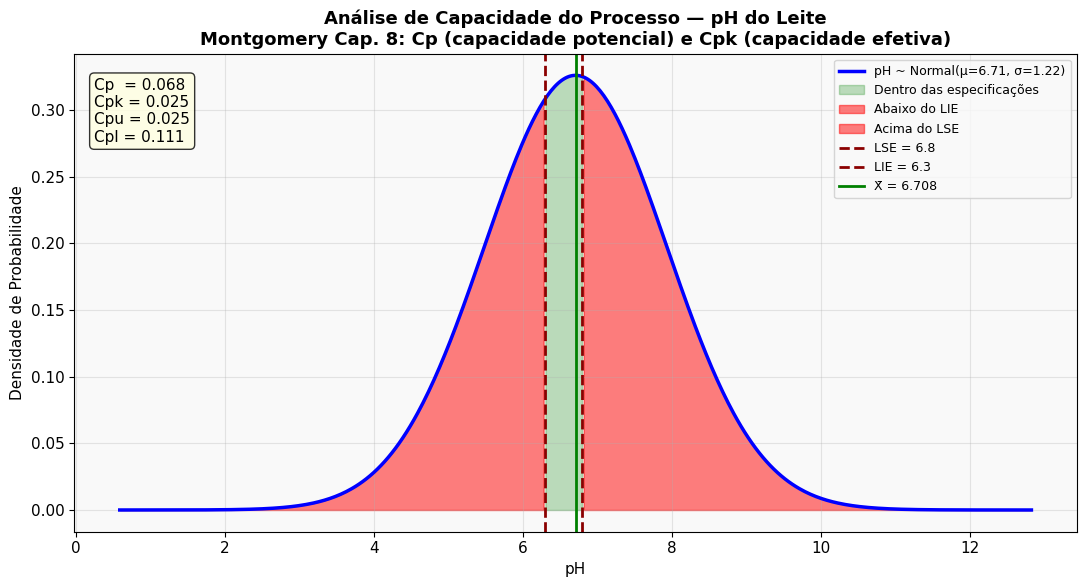

[Fig. 5 salva] Análise de capacidade gerada.


In [ ]:
print("\n" + "=" * 70)
print("ETAPA 5: ANÁLISE DE CAPACIDADE DO PROCESSO (Cp e Cpk)")
print("Ref.: Montgomery Cap. 6, Seção 6.2 | Cap. 8, Seções 8.3.1 e 8.3.2")
print("=" * 70)

LSE = 6.80
LIE = 6.30

print(f"\n  Limites de Especificação definidos:")
print(f"  LSE (Limite Superior) = {LSE}")
print(f"  LIE (Limite Inferior) = {LIE}")
print(f"\n  Parâmetros do processo (estimados via Fase I, Carta X-MR):")
print(f"  μ̂ = X̄  = {X_bar:.4f}")
print(f"  σ̂ = MR̄/d2 = {sigma_hat:.4f}  (d2 = {d2} para n=2, Apêndice VI)")

Cp  = (LSE - LIE) / (6 * sigma_hat)
Cpu = (LSE - X_bar) / (3 * sigma_hat)
Cpl = (X_bar - LIE) / (3 * sigma_hat)
Cpk = min(Cpu, Cpl)

print(f"\n  Razões de Capacidade (Montgomery, Cap. 8, Eq. 8.4 e 8.9):")
print(f"  Cp  = {Cp:.4f}  (capacidade potencial — processo centrado)")
print(f"  Cpu = {Cpu:.4f}  (capacidade em relação ao LSE)")
print(f"  Cpl = {Cpl:.4f}  (capacidade em relação ao LIE)")
print(f"  Cpk = {Cpk:.4f}  (capacidade efetiva — considera descentramento)")

print("\n  Interpretação (Montgomery, Tabela 8.3 — Valores Mínimos Recomendados):")
def interpretar_cp(cp, nome):
    if cp >= 1.67:
        return f"  {nome} = {cp:.3f} → ✓ EXCELENTE (≥ 1,67)"
    elif cp >= 1.50:
        return f"  {nome} = {cp:.3f} → ✓ BOM (≥ 1,50)"
    elif cp >= 1.33:
        return f"  {nome} = {cp:.3f} → ✓ ADEQUADO (≥ 1,33 — mínimo recomendado)"
    elif cp >= 1.00:
        return f"  {nome} = {cp:.3f} → ⚠️ MARGINAL (≥ 1,00 — melhorias necessárias)"
    else:
        return f"  {nome} = {cp:.3f} → ✗ INADEQUADO (< 1,00 — processo incapaz)"

print(interpretar_cp(Cp,  "Cp "))
print(interpretar_cp(Cpk, "Cpk"))

delta = Cp - Cpk
if delta < 0.1:
    print(f"\n  Cp - Cpk = {delta:.3f} → processo aproximadamente centrado")
else:
    print(f"\n  Cp - Cpk = {delta:.3f} → processo DESCENTRADO")
    print(f"  (X̄={X_bar:.3f} deslocado do ponto médio das especificações = {(LSE+LIE)/2:.3f})")

if normalidade_ok:
    z_sup = (LSE - X_bar) / sigma_hat
    z_inf = (LIE - X_bar) / sigma_hat
    ppm_acima  = (1 - stats.norm.cdf(z_sup)) * 1e6
    ppm_abaixo = stats.norm.cdf(z_inf) * 1e6
    ppm_total  = ppm_acima + ppm_abaixo
    print(f"\n  Estimativa de não-conformidades:")
    print(f"  PPM acima do LSE:  {ppm_acima:,.1f}")
    print(f"  PPM abaixo do LIE: {ppm_abaixo:,.1f}")
    print(f"  PPM TOTAL:         {ppm_total:,.1f}  (ref. Montgomery Tab. 8.2)")
else:
    print("\n  ⚠️ PPM não calculado: pressuposto de normalidade rejeitado.")

fig, ax = plt.subplots(figsize=(11, 6))
x_range = np.linspace(X_bar - 5 * sigma_hat, X_bar + 5 * sigma_hat, 500)
y_norm  = stats.norm.pdf(x_range, X_bar, sigma_hat)

ax.plot(x_range, y_norm, 'b-', linewidth=2.5,
        label=f'pH ~ Normal(μ={X_bar:.2f}, σ={sigma_hat:.2f})')
ax.fill_between(x_range, y_norm,
                where=(x_range >= LIE) & (x_range <= LSE),
                alpha=0.25, color='green', label='Dentro das especificações')
ax.fill_between(x_range, y_norm, where=(x_range < LIE),
                alpha=0.5, color='red', label='Abaixo do LIE')
ax.fill_between(x_range, y_norm, where=(x_range > LSE),
                alpha=0.5, color='red', label='Acima do LSE')

ax.axvline(LSE,   color='darkred', linestyle='--', linewidth=2, label=f'LSE = {LSE}')
ax.axvline(LIE,   color='darkred', linestyle='--', linewidth=2, label=f'LIE = {LIE}')
ax.axvline(X_bar, color='green',   linestyle='-',  linewidth=2, label=f'X̄ = {X_bar:.3f}')

textstr = f'Cp  = {Cp:.3f}\nCpk = {Cpk:.3f}\nCpu = {Cpu:.3f}\nCpl = {Cpl:.3f}'
props = dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes,
        fontsize=11, verticalalignment='top', bbox=props)

ax.set_title('Análise de Capacidade do Processo — pH do Leite\n'
             'Montgomery Cap. 8: Cp (capacidade potencial) e Cpk (capacidade efetiva)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('pH')
ax.set_ylabel('Densidade de Probabilidade')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig("fig5_capacidade.png", dpi=150)
plt.show()
print("[Fig. 5 salva] Análise de capacidade gerada.")

**Etapa 6: Diagnóstico Final e Plano de Ação**

A última etapa consolida todos os resultados e propõe um Plano de Ação para Fora de Controle, o PAFC, descrito na Seção 5.2 do Montgomery.

O PAFC é estruturado em quatro níveis: investigação imediata dos lotes sinalizados, ação corretiva no processo, ação preventiva de longo prazo e revisão periódica dos limites. Montgomery recomenda revisar os limites de controle a cada 25 a 50 novas amostras. Para processos onde a Fase II exige maior sensibilidade a pequenos deslocamentos, o próprio Montgomery sugere migrar para cartas CUSUM ou MMEP, abordadas no Capítulo 9.

In [ ]:
print("\n" + "=" * 70)
print("ETAPA 6: DIAGNÓSTICO FINAL E PLANO DE AÇÃO (PAFC)")
print("Ref.: Montgomery Cap. 5, Seção 5.2")
print("=" * 70)

print(f"""
  RESUMO DO PROCESSO DE pH DO LEITE
  ──────────────────────────────────────────────────────────────────
  Parâmetros do processo (Fase I, n={N_FASE1} amostras):
    X̄  = {X_bar:.4f}  |  σ̂ = {sigma_hat:.4f}
    LSC = {lsc_X:.4f}  |  LIC = {lic_X:.4f}

  Normalidade (Shapiro-Wilk):
    {"✓ Pressuposto atendido — interpretação de Cp/Cpk válida" if normalidade_ok else "⚠️ Pressuposto violado — interpretar Cp/Cpk com cautela"}

  Capacidade do Processo:
    Cp  = {Cp:.3f} → {"ADEQUADO (≥1,33)" if Cp  >= 1.33 else "INADEQUADO (<1,33)"}
    Cpk = {Cpk:.3f} → {"ADEQUADO (≥1,33)" if Cpk >= 1.33 else "INADEQUADO (<1,33)"}

  Regras da Western Electric (Fase II, {n} amostras):
    Total de sinais de fora de controle: {total_ooc}
  ──────────────────────────────────────────────────────────────────
""")

if total_ooc > 0 or Cpk < 1.33:
    print("""  PLANO DE AÇÃO (PAFC) — Montgomery Cap. 5, Seção 5.2:

  1. INVESTIGAÇÃO IMEDIATA:
     → Identificar lotes correspondentes às amostras sinalizadas
     → Calibrar potenciômetros de medição de pH
     → Verificar temperatura de armazenamento e cadeia de frio

  2. AÇÃO CORRETIVA:
     → Se Cpk < 1,33: revisar parâmetros de processo para centralizar a média
     → Se R1 ativada: interromper lote e realizar inspeção 100%

  3. AÇÃO PREVENTIVA:
     → Implementar subgrupos racionais (Cap. 5): amostragem por turno
     → Considerar cartas CUSUM ou MMEP (Cap. 9) para maior sensibilidade
       a pequenos deslocamentos na Fase II

  4. REVISÃO DOS LIMITES:
     → Revisar limites a cada 25–50 novas amostras (Montgomery Cap. 6)
     → Monitorar também temperatura e turbidez (CTQs adicionais
       identificados na análise de importância)
  """)
else:
    print("  PROCESSO ESTÁVEL E CAPAZ: operando sob controle estatístico.")
    print("  → Manter cadência de amostragem e revisar limites periodicamente.")

print("\n" + "=" * 70)
print("Figuras salvas: fig1_correlacao.png | fig2_importancia.png |")
print("                fig3_normalidade.png | fig4_cartas_xmr.png |")
print("                fig5_capacidade.png")
print("=" * 70)


ETAPA 6: DIAGNÓSTICO FINAL E PLANO DE AÇÃO (PAFC)
Ref.: Montgomery Cap. 5, Seção 5.2

  RESUMO DO PROCESSO DE pH DO LEITE
  ──────────────────────────────────────────────────────────────────
  Parâmetros do processo (Fase I, n=100 amostras):
    X̄  = 6.7080  |  σ̂ = 1.2241
    LSC = 10.3804  |  LIC = 3.0356

  Normalidade (Shapiro-Wilk):
    ⚠️ Pressuposto violado — interpretar Cp/Cpk com cautela

  Capacidade do Processo:
    Cp  = 0.068 → INADEQUADO (<1,33)
    Cpk = 0.025 → INADEQUADO (<1,33)

  Regras da Western Electric (Fase II, 959 amostras):
    Total de sinais de fora de controle: 71
  ──────────────────────────────────────────────────────────────────

  PLANO DE AÇÃO (PAFC) — Montgomery Cap. 5, Seção 5.2:

  1. INVESTIGAÇÃO IMEDIATA:
     → Identificar lotes correspondentes às amostras sinalizadas
     → Calibrar potenciômetros de medição de pH
     → Verificar temperatura de armazenamento e cadeia de frio

  2. AÇÃO CORRETIVA:
     → Se Cpk < 1,33: revisar parâmetros de pr